In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv
from functools import reduce
from sklearn.decomposition import PCA
import multiprocessing as mp
from multiprocessing import Pool
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier
import scour.scour
import gzip

In [2]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [3]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
n_clusters=500
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [4]:
file_path=os.path.join(cluster_dir, 'model_set_total.pkl')
# with open(file_path, 'wb') as file:
#         pickle.dump(model_set, file)
with open(file_path, 'rb') as file:
    model_set = pickle.load(file)

In [5]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#727272',
    'un':'orange'
}

In [6]:
def create_dark_to_color_cmap(color):
    """Create colormap from black to specified color"""
    return matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['#FFADAD',color,color]) # '#70CDFF'

In [7]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape
anat_uint=anat_high_res.astype('uint8')

In [8]:
atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')


(1256, 584, 363)


In [9]:
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files=os.path.join(cluster_dir,file)
giant_total_labels=np.load(label_files)
print(giant_total_labels.shape)

(4171804,)


In [10]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
print(giant_labels_anat.shape)

(314, 146, 91)


In [11]:
nx,ny,nz=atlas.shape
ox,oy,oz=giant_labels_anat.shape
# scale_factors = (nx/ox, ny/oy, nz/oz)
scale_factors = (ox/nx, oy/ny, oz/nz)
# Resample using zoom with cubic interpolation (order=3)
anat_lowres = zoom(anat_high_res, scale_factors, order=3)
atlas_lowres = zoom(atlas_int, scale_factors, order=3)

In [12]:
print(anat_lowres.shape)
# atlas_int = anat_lowres.astype('uint8')

(314, 146, 91)


In [13]:
ids,counts=np.unique(model_set['top_100'], return_counts=True)
top_ids=ids[np.argsort(counts)[::-1]][:100]
top_counts=counts[np.argsort(counts)[::-1]][:100]

In [14]:
top_100=np.asarray(model_set['top_100'])
top_import=np.asarray(model_set['top_import'])
new_importances={}
for i in top_ids:
    new_importances[i]=[]
for i in top_ids:
#     print(i)
    for j,x in enumerate(top_import):
#         print(x)
        importance_vals=x
        val=importance_vals[np.isin(top_100[j,:],i)]
        new_importances[i].append(val)
    new_importances[i]=np.hstack(new_importances[i])

In [15]:
top_importances_final=[]
for ids in new_importances:
    top_importances_final.append(np.mean(new_importances[ids]))
top_importances_final=np.asarray(top_importances_final)

In [16]:
order=np.argsort(top_importances_final)[::-1]
ids=top_ids[order]
count=top_counts[order]
importance=top_importances_final[order]

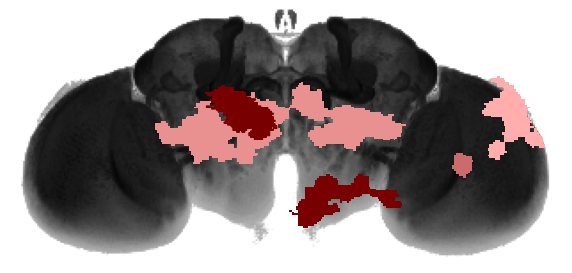

In [17]:
amt=5
# print(np.shape(cluster_importances[b]))
fig,ax=plt.subplots(figsize=(10,10))
plt.imshow(np.max(anat_lowres, axis=-1).T,cmap='gray_r');
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,ids[:amt]),giant_labels_anat,np.nan)
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=create_dark_to_color_cmap('#780000'))
ax.axis('off');
# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_loc.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_loc.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [ ]:
roi_atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [ ]:
def explode_plot(brain,vmax,explosion_rois,roi_masks,roi_contours,tp=None,cmap='seismic'):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    if tp==None:
        data_to_plot = brain[:,:,::-1]
    else:
        data_to_plot = brain[tp][:,:,::-1]
    vmax =vmax #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap, diverging=False)#'hot')
    return explosion_map

In [ ]:
ax_as=1.5
vmax=np.nanmax(labels_anat_sub_total)
fig,axs=plt.subplots(figsize=(10,10))
temp=explode_plot(np.nan_to_num(labels_anat_sub_total),vmax,explosion_rois,roi_masks,roi_contours,cmap=create_dark_to_color_cmap('#780000'))
brain=axs.imshow(temp[170:,:]) #this was made with cmap=hot
axs.axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
axs.set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'top{amt}_explosion.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'top{amt}_explosion.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [ ]:
be=['dec','flat','inc']
cm = confusion_matrix(y_predict_final, y_idxs_final)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cm_percent, ax=ax, cmap='YlGn');
ax.xaxis.set_ticks([]);
ax.yaxis.set_ticks([]);
# _ = ax.set_title(
#     f"Confusion Matrix for {rf.__class__.__name__}"
# )

# plt.savefig(os.path.join(save_dir,f'confusion_matrix_{rf.__class__.__name__}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'onfusion_matrix_randomforest.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [ ]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [ ]:
event1='new_best_5sec'
# event2='best'
n_clusters=500
label_files=[]
cluster_files=[]
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files.append(file)
    elif f'_{n_clusters}_' in file and 'clusters' in file and event1 in file:
        cluster_files.append(file)

## Load supervox

In [ ]:
cluster_files

In [ ]:
%%time
best_cluster_path_5sec=os.path.join(cluster_dir,cluster_files[0])
# best_cluster_path=os.path.join(cluster_dir,cluster_files[1])
print(best_cluster_path_5sec)
with open(best_cluster_path_5sec, 'rb') as file:
    five_sec = pickle.load(file)
    print(five_sec.keys())

# with open(best_cluster_path, 'rb') as file:
#     best = pickle.load(file)
#     print(best.keys())
    

In [ ]:
label_files

In [ ]:
%%time
best_label_path=os.path.join(cluster_dir,label_files[0])
print(best_label_path)
giant_total_labels=np.load(best_label_path)
print(giant_total_labels.shape)

In [ ]:
giant_total_anat=giant_total_labels.reshape(314,146,91)


In [ ]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25']) #,  '#6d0d25'
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [ ]:
giant_total_anat.shape

In [ ]:
fixed = brainsss.load_fda_meanbrain()
behaviors=list(five_sec.keys())

In [ ]:
# ax_ap=0.1
# superclust_dict=best
# fig,axs=plt.subplots(1,3,figsize=(10,10))
# axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
# axs[0].set_aspect(ax_ap)
# axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
# axs[1].set_aspect(ax_ap)
# axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
# axs[2].set_aspect(ax_ap)
# plt.tight_layout()

ax_ap=0.2
start=15
end=40
superclust_dict=five_sec
fig,axs=plt.subplots(1,4,figsize=(20,10))
axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
axs[0].set_aspect(ax_ap)
axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
axs[1].set_aspect(ax_ap)
axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
axs[2].set_aspect(ax_ap)
axs[3].imshow(superclust_dict['non'],  vmax=0.01,vmin=-0.01)
axs[3].set_aspect(ax_ap)
plt.tight_layout()

In [ ]:
superclust_dict_z={}
for behavior in five_sec:
    print(behavior)
    signals_total_z=scipy.stats.zscore(five_sec[behavior][:,14:41],axis=1)
    superclust_dict_z[behavior]=signals_total_z

In [ ]:
ids[:5]

In [ ]:
ax_ap=1
vmax=2
vmin=-2
clusters=ids[:5]
# not_in=~np.isin(np.arange(500),rois)
fig,ax=plt.subplots(3,1,figsize=(20,10))
b='flat'
ax[0].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
ax[0].set_yticks([])
ax[0].set_xticks([])
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[0].axvline(x=6.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
ax[0].axvline(x=16.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
b='inc'
ax[1].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
ax[1].set_yticks([])
ax[1].set_xticks([])
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['left'].set_visible(False)
ax[1].spines['bottom'].set_visible(False)
ax[1].axvline(x=6.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
ax[1].axvline(x=16.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
b='dec'
ax[2].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)
ax[2].set_yticks([])
ax[2].set_xticks([])
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)
ax[2].spines['left'].set_visible(False)
ax[2].spines['bottom'].set_visible(False)
ax[2].axvline(x=6.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
ax[2].axvline(x=16.5, ymin=0, ymax=1, ls='--', color='k', lw=4)
# plt.savefig(os.path.join(save_dir,f'commonvals_activity.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'commonvals_activity.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [ ]:
fig,axs=plt.subplots(figsize=(10,10))
# rois=best_clus_dict[comp]
behaves=['inc','dec','flat','non']
plot_dict=superclust_dict_z
for behave in behaves:
    mean_trace=gaussian_filter1d(np.mean(plot_dict[behave][clusters,:],axis=0),sigma=1)
    error_trace=np.std(gaussian_filter1d(plot_dict[behave][clusters,:],sigma=1),axis=0)
    if behave != 'non':
    #     error_trace=scipy.stats.sem(gaussian_filter1d(plot_dict[behave][clusters,:],sigma=1),axis=0)
        axs.plot(mean_trace,color=behavior_colors[behave], label=behave)
        axs.fill_between(np.arange(len(mean_trace)),mean_trace-error_trace, mean_trace+error_trace, color='#e0e0df',alpha=0.5)
    else:
        axs.plot(mean_trace,color=behavior_colors[behave],ls='--', label=behave)
x1=6;x2=16
axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
# axs.set_xticklabels([])
# axs.set_yticklabels([])
axs.tick_params(axis='y', labelsize=20) 
# plt.savefig(os.path.join(save_dir,f'commonvals_time_trace.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'commonvals_time_trace.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [ ]:
behave_lst[fly]['total'].shape

In [ ]:
behave_lst[fly]['total'][0]

In [ ]:
fig,axs=plt.subplots(figsize=(10, 8))
# plt.scatter(total_pre, total_post);
behavior_set=total_behavior
key_order=['total','non','inc','dec','flat']
for key in key_order:
#     print(key)
    if key is not 'total':
        axs.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=50,color=behavior_colors[key], label=key);
    else:
        axs.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=50, color='k', label=key);
        
# plt.axvline(0,color='k',linestyle='--',lw=2);
# plt.axhline(0,color='k',linestyle='--',lw=2);
# plt.legend();
axs.set_xlabel('Avg velocity 50ms before stim');
axs.set_ylabel('Avg velocity 50ms before end of stim');
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
# axs.spines['bottom'].set_visible(False)
# axs.spines['left'].set_visible(False)
# plt.savefig(os.path.join(save_dir,'total_avg_scatter.png'), dpi=300, bbox_inches='tight')

In [ ]:
fly_clust.keys()

In [ ]:
len(total_behavior['inc'])

In [ ]:
pie={'inc':len(total_behavior['inc']),'dec':len(total_behavior['dec']),'flat':len(total_behavior['flat'])}

def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%"


pie_col=['#FC00B9','#17D4DE','#000000']
fig, ax = plt.subplots(figsize=(10,10))
ax.pie(x=list(pie.values()), colors=pie_col,autopct=lambda pct: func(pct, list(pie.values())),textprops=dict(color="w",size=40));
# plt.savefig(os.path.join(save_dir,'model_pie.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'OG_pie.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

